# Imports

In [1]:
!pip install pytabkit skorch pytorch-tabular[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [2]:
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier, RealMLP_HPO_Classifier, TabR_HPO_Classifier, RealTabR_D_Classifier, TabR_S_D_Classifier
from pytorch_tabular import TabularModel
from pytorch_tabular.models import GANDALFConfig, DANetConfig, TabNetModelConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import torchmetrics
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

# Global Configuration

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
N_FOLDS = 5

print(f"Using device: {DEVICE}")

Using device: cuda


# Data Loading and Preprocessing

In [4]:
train = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")
original = pd.read_csv("/kaggle/input/datasets/cdeotte/s6e4-original-dataset/Heart_Disease_Prediction.csv") 

le = LabelEncoder()
train['Heart Disease'] = le.fit_transform(train['Heart Disease'])
original['Heart Disease'] = le.fit_transform(original['Heart Disease'])

base_features = [col for col in train.columns if col not in ['Heart Disease', 'id']] 

def add_engineered_features(df):
    df_temp = df.copy()
    
    for col in base_features: 
        if col in original.columns:
           
            stats = original.groupby(col)['Heart Disease'].agg(['mean', 'median', 'std', 'skew', 'count']).reset_index()
         
            stats.columns = [col] + [f"orig_{col}_{s}" for s in ['mean', 'median', 'std', 'skew', 'count']]
     
            df_temp = df_temp.merge(stats, on=col, how='left') 
 
            fill_values = {
                f"orig_{col}_mean": original['Heart Disease'].mean(),
                f"orig_{col}_median": original['Heart Disease'].median(),
                f"orig_{col}_std": 0,
                f"orig_{col}_skew": 0,
                f"orig_{col}_count": 0
            }
            df_temp = df_temp.fillna(value=fill_values)
            
    return df_temp

train = add_engineered_features(train)
test = add_engineered_features(test) 

X = train.drop(['id', 'Heart Disease'], axis=1)
y = train['Heart Disease']
X_test = test.drop(['id'], axis=1)

# Data Quality Check (Missing & Duplicates)

In [5]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()
    
    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


# Feature Uniqueness & Cardinality

In [6]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id': continue
        
        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"
        
        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })
    
    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
print(uniqueness_df)

                     Feature  Unique Values Data Type       Heuristic Type
40  orig_FBS over 120_median              1   float64  Categorical/Ordinal
1                        Sex              2     int64  Categorical/Ordinal
13             Heart Disease              2     int64  Categorical/Ordinal
5               FBS over 120              2     int64  Categorical/Ordinal
20           orig_Sex_median              2   float64  Categorical/Ordinal
..                       ...            ...       ...                  ...
0                        Age             42     int64           Continuous
3                         BP             66     int64           Continuous
9              ST depression             66   float64           Continuous
7                     Max HR             93     int64           Continuous
4                Cholesterol            150     int64           Continuous

[79 rows x 4 columns]


# Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
orig_EKG results_count   -15.613416
orig_EKG results_std       6.747575
orig_Slope of ST_count    -5.657311
orig_Thallium_std          4.472673
orig_BP_std               -4.174508
orig_Age_std              -3.145546
dtype: float64


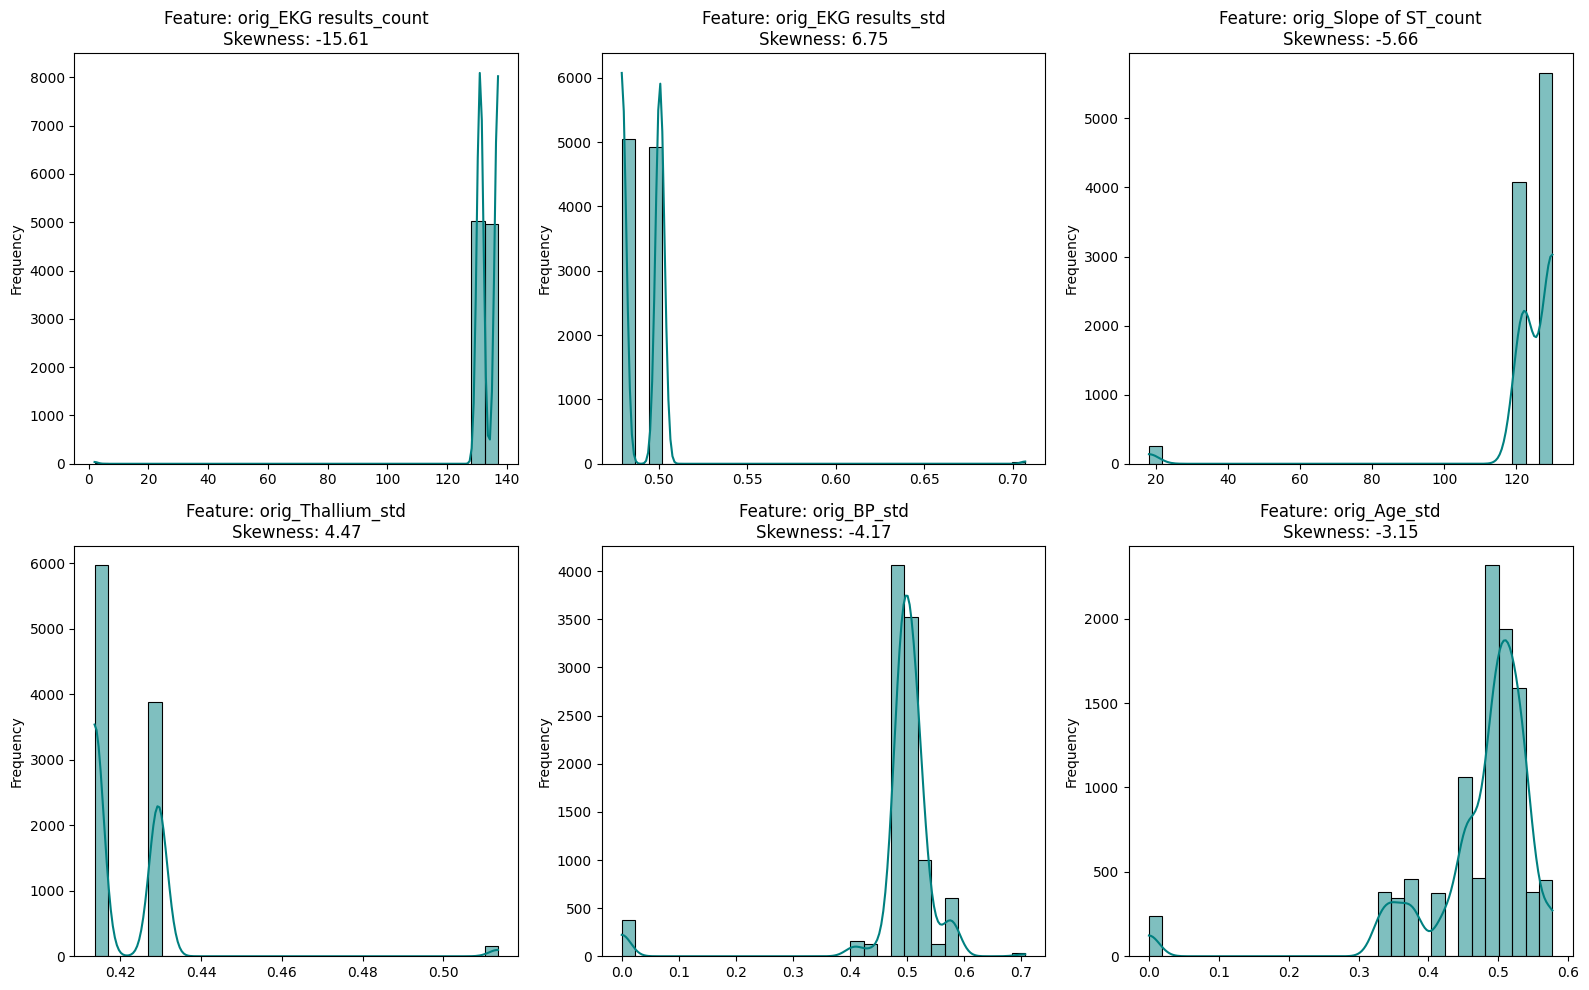

In [7]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1) 
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('skewed_distributions.png')

# Cross-Validation & Training

In [8]:
# !set PYTORCH_CUDA_ALLOC_CONF="expandable_segments:True"

In [9]:
# import multiprocessing

# logical_cores = multiprocessing.cpu_count()

# if logical_cores is not None:
#     print(f"Number of CPU threads (logical cores): {logical_cores}")
# else:
#     print("Could not determine CPU count")


In [10]:
# import inspect
# from pytorch_tabular.models import TabNetModelConfig
# print(inspect.signature(TabNetModelConfig.__init__))

In [11]:
# %%time

# cat_features = [col for col in X.columns if not col.endswith('_num')]
# num_features = [f'{col}_num' for col in base_features]

# for col in cat_features:
#     train[col] = train[col].astype(str).astype('category')
#     test[col] = test[col].astype(str).astype('category')
#     train[f'{col}_num'] = train[col].astype('float32')
#     test[f'{col}_num'] = test[col].astype('float32')

# data_config = DataConfig(
#     target=['Heart Disease'], 
#     continuous_cols=num_features,
#     categorical_cols=cat_features, 
# )

# trainer_config = TrainerConfig(
#     batch_size=1024,
#     max_epochs=15,
#     accelerator='gpu',
#     early_stopping_patience=5,
#     progress_bar="none",
# )

# oof_preds = np.zeros(len(train))
# test_preds = np.zeros(len(test))
# fold_scores = [] 
# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#     print(f"\n--- Starting Fold {fold + 1} ---")

#     train_df = train.iloc[train_idx]
#     val_df = train.iloc[val_idx]

#     model_config = DANetConfig(
#         task='classification',
#         n_layers=8,              # From your signature: n_layers: int = 8
#         abstlay_dim_1=32,        # From your signature: abstlay_dim_1: int = 32
#         abstlay_dim_2=64,        # Optional, but usually 2x dim_1 is a good start
#         k=5,                     # From your signature: k: int = 5
#         dropout_rate=0.1,        # From your signature: dropout_rate: float = 0.1
#         learning_rate=0.01,
#         virtual_batch_size=256   # From your signature: virtual_batch_size: int = 256
#     )

#     tabular_model = TabularModel(
#         data_config=data_config,
#         model_config=model_config,
#         optimizer_config=OptimizerConfig(),
#         trainer_config=trainer_config,
#         verbose=False,
#     )

#     tabular_model.fit(train=train_df, validation=val_df,
#                      metrics=[torchmetrics.functional.auroc],  
#                         metrics_prob_inputs=[True],
#                         # metrics_params=[{"task": "binary"}]
#                      )


#     val_results = tabular_model.predict(val_df)
#     test_results = tabular_model.predict(test)

#     val_probs = val_results['Heart Disease_1_probability'].values
#     test_probs = test_results['Heart Disease_1_probability'].values

#     oof_preds[val_idx] = val_probs
#     test_preds += test_probs / N_FOLDS

#     score = roc_auc_score(y.iloc[val_idx], val_probs)
#     fold_scores.append(score)
#     print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

In [12]:
%%time

cat_features = [col for col in X.columns if not col.endswith('_num')]
num_features = [f'{col}_num' for col in base_features]

for col in cat_features:
    train[col] = train[col].astype(str).astype('category')
    test[col] = test[col].astype(str).astype('category')
    train[f'{col}_num'] = train[col].astype('float32')
    test[f'{col}_num'] = test[col].astype('float32')

data_config = DataConfig(
    target=['Heart Disease'], 
    continuous_cols=num_features,
    categorical_cols=cat_features, 
)


trainer_config = TrainerConfig(
    batch_size=1024,
    max_epochs=15,
    accelerator='gpu',
    early_stopping_patience=7,
    progress_bar="none"
)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_scores = [] 
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Starting Fold {fold + 1} ---")

    train_df = train.iloc[train_idx]
    val_df = train.iloc[val_idx]
    
    model_config = TabNetModelConfig(
        task='classification',
        n_d=32,
        n_a=32,
        n_steps=5,
       # Structural Params
        gamma=1.3,                      # From your signature: relaxation factor
        n_independent=2,                # Independent GLU blocks
        n_shared=2,                     # Shared GLU blocks
        mask_type='sparsemax',          # From your signature: ensures sparse selection
        
        # Training Params
        virtual_batch_size=128,         # From your signature: for Ghost Batch Norm
        learning_rate=0.01
        )
    
    tabular_model = TabularModel(
        data_config=data_config,
        model_config=model_config,
        optimizer_config=OptimizerConfig(),
        trainer_config=trainer_config,
        verbose=False,
    )

    tabular_model.fit(train=train_df, validation=val_df,
                     metrics=[torchmetrics.functional.auroc],  
                        metrics_prob_inputs=[True],
                        # metrics_params=[{"task": "binary"}]
                     )


    val_results = tabular_model.predict(val_df)
    test_results = tabular_model.predict(test)

    val_probs = val_results['Heart Disease_1_probability'].values
    test_probs = test_results['Heart Disease_1_probability'].values

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / N_FOLDS

    score = roc_auc_score(y.iloc[val_idx], val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


--- Starting Fold 1 ---


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2026-02-26 09:33:07.712042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772098387.896480      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772098387.950136      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772098388.409791      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772098388.409819      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more tha

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _embedding_layer │ Identity         │      0 │ train │     0 │
│ 1 │ _backbone        │ TabNetBackbone   │  213 K │ train │     0 │
│ 2 │ _head            │ Identity         │      0 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 213 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 213 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 234                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=15` reached.


...

Fold 4 ROC-AUC Score: 0.94555

--- Starting Fold 5 ---


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _embedding_layer │ Identity         │      0 │ train │     0 │
│ 1 │ _backbone        │ TabNetBackbone   │  213 K │ train │     0 │
│ 2 │ _head            │ Identity         │      0 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 213 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 213 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 234                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Fold 5 ROC-AUC Score: 0.94876
CPU times: user 1h 14min 36s, sys: 17.8 s, total: 1h 14min 53s
Wall time: 58min 20s


In [13]:
# %%time

# param_grid = {
#         'device': 'cuda',
#         'random_state': 42,
#         'verbosity': 2,
#         'n_epochs': 100,
#         'batch_size': 256, 
#         'n_ens': 8, 
#         'use_early_stopping': True,
#         'early_stopping_additive_patience': 20,
#         'early_stopping_multiplicative_patience': 1,
#         'act': "mish",
#         'embedding_size': 8,
#         'first_layer_lr_factor': 0.5962121993798933,
#         'hidden_sizes': "rectangular",
#         'hidden_width': 384,
#         'lr': 0.01,
#         'ls_eps': 0.0,
#         'ls_eps_sched': "coslog4",
#         'max_one_hot_cat_size': 18,
#         'n_hidden_layers': 3,
#         'p_drop': 0.1,
#         'p_drop_sched': "flat_cos",
#         'plr_hidden_1': 16,
#         'plr_hidden_2': 8,
#         'plr_lr_factor': 0.1151437622270563,
#         'plr_sigma': 2.3316811282666916,
#         'scale_lr_factor': 2.244801835541429,
#         'sq_mom': 1.0 - 0.011834054955582318,
#         'wd': 0.02369230879235962,
#     } 

# param_grid2 = {
#     'n_epochs': 16,  # ← REDUCE from default 100,000
#     'device': 'cuda',
#     'n_threads': 4,
#     'batch_size': 512,  # ← INCREASE from default 256
#     'eval_batch_size': 512,  # ← ADD THIS
#     'context_size': 8,  # ← INCREASE from default 96 (reduces FAISS overhead)
#     'patience': 4,  # ← ADD THIS - early stopping patience (default 16)
#     'optimizer': {
#         'type': 'AdamW',
#         'lr': 0.01,
#         'weight_decay': 1e-6
#     }
# }

# for col in X.columns:
#     X[col] = X[col].astype(str).astype('category')
#     X_test[col] = X_test[col].astype(str).astype('category') 

# for col in base_features:
#     X[f'{col}_num'] = X[col].astype('float32')
#     X_test[f'{col}_num'] = X_test[col].astype('float32')

# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# strat_cols = ['Thallium', 'Chest pain type', 'Heart Disease']
# le = LabelEncoder()
# stratify_feature = le.fit_transform(train[strat_cols].astype(str).agg('_'.join, axis=1))

# oof_preds = np.zeros(len(train))
# test_preds = np.zeros(len(test))
# fold_scores = [] 

# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#     print(f"\n--- Starting Fold {fold + 1} ---")

#     X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx] 

#     model = TabR_S_D_Classifier(**param_grid2) 
#     model.fit(X_tr, y_tr.values, X_val, y_val.values) 

#     val_probs = model.predict_proba(X_val)[:, 1] 
#     fold_test_probs = model.predict_proba(X_test)[:, 1] 

#     oof_preds[val_idx] = val_probs
#     test_preds += fold_test_probs / N_FOLDS

#     score = roc_auc_score(y_val, val_probs)
#     fold_scores.append(score)
#     print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

#     if DEVICE == 'cuda':
#         torch.cuda.empty_cache()

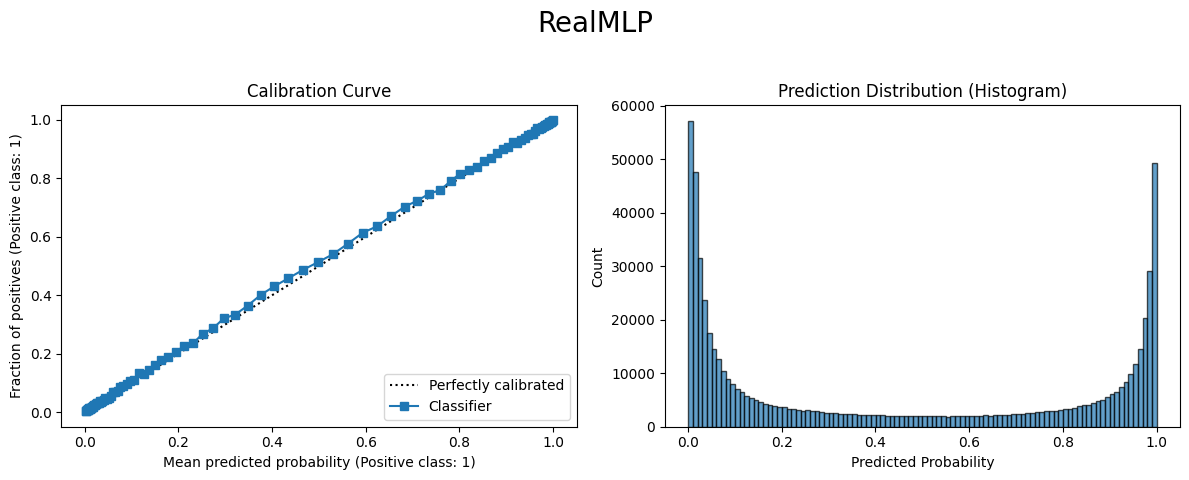

In [14]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5)) 
plt.suptitle('RealMLP', fontsize=20) 

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Evaluation and Submission

In [15]:
total_oof_score = roc_auc_score(y, oof_preds) 

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print("="*40)

pd.DataFrame({'id': train['id'], 'Heart Disease_prob': oof_preds}).to_csv(f'oof_tabnet_{total_oof_score}.csv', index=False)

submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv(f'submission_tabnet_{total_oof_score}.csv', index=False)
submission.head() 


Overall OOF ROC-AUC: 0.94937
Mean Fold Score: 0.94973 (+/- 0.00255)


,id,Heart Disease
0,630000,0.876825
1,630001,0.007396
2,630002,0.990338
3,630003,0.006496
4,630004,0.341921
